In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


Device: cuda


In [27]:
with open("..\\Dataset\\viol_analysis_results.pkl", 'rb') as f:
    viol_info = pickle.load(f)

viol = viol_info['original']

In [28]:
#Train-test split
SPLIT = int(len(viol) * 0.8)
train_orig = viol.iloc[:SPLIT]
test_orig  = viol.iloc[SPLIT:]

print(f"Train : {train_orig.index[0].date()} to {train_orig.index[-1].date()}  ({len(train_orig)} months)")
print(f"Test  : {test_orig.index[0].date()}  to {test_orig.index[-1].date()}  ({len(test_orig)} months)")

Train : 2021-11-01 to 2023-09-01  (23 months)
Test  : 2023-10-01  to 2024-03-01  (6 months)


In [29]:
#Normalisation on train data
v_min, v_max = train_orig.min(), train_orig.max()
norm   = lambda x: (x - v_min) / (v_max - v_min)
denorm = lambda x:  x * (v_max - v_min) + v_min

norm_series = norm(viol)
train_n     = norm_series.iloc[:SPLIT]
test_n      = norm_series.iloc[SPLIT:]

In [30]:
class LinearTrendModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(1, 1)

    def forward(self, x):
        return self.fc(x)
    
class LinearRegressionModel(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.fc = nn.Linear(in_dim, 1)

    def forward(self, x):
        return self.fc(x)
    
def train_linear(model, X_np, y_np, epochs=1000, lr=0.01):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.MSELoss()

    X = torch.tensor(X_np, dtype=torch.float32).to(device)
    y = torch.tensor(y_np, dtype=torch.float32).to(device)

    losses = []
    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X).squeeze(), y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    return losses

def build_lag_features(series, lags=[1, 2, 3, 12]):
    df = pd.DataFrame({'y': series})

    for l in lags:
        df[f'lag{l}'] = series.shift(l)

    df['trend'] = np.arange(len(series), dtype=np.float32)

    #Maintaing locality across the end of a year via sin/cos periodicity
    df['month_sin'] = np.sin(2 * np.pi * series.index.month / 12)
    df['month_cos'] = np.cos(2 * np.pi * series.index.month / 12)

    return df.dropna()

def evaluate(actual, predicted, name):
    a = np.array(actual).flatten()
    p = np.array(predicted).flatten()
    n = min(len(a), len(p))
    a, p = a[:n], p[:n]

    mae  = mean_absolute_error(a, p)
    rmse = np.sqrt(mean_squared_error(a, p))
    mape = np.mean(np.abs((a - p) / np.where(a == 0, 1e-8, a))) * 100

    return {'Model': name,
            'MAE':  round(mae,  2),
            'RMSE': round(rmse, 2),
            'MAPE': round(mape, 2)}

In [31]:
#Non-Lag model
X_tr_trend = np.arange(len(train_n),   dtype=np.float32).reshape(-1, 1)
X_te_trend = np.arange(len(train_n), len(norm_series),
                        dtype=np.float32).reshape(-1, 1)

trend_model  = LinearTrendModel()
losses_trend = train_linear(
    trend_model,
    X_tr_trend,
    train_n.values.astype(np.float32),
    epochs=1000, lr=0.01
)

trend_model.eval()
with torch.no_grad():
    pred_trend = denorm(
        trend_model(torch.tensor(X_te_trend).to(device))
        .squeeze().cpu().numpy()
    )

print(f"Final training loss without Lag features: {losses_trend[-1]:.6f}")


Final training loss without Lag features: 0.095438


In [32]:
feat_all = build_lag_features(norm_series)

feat_train = feat_all.iloc[:SPLIT - 12]
feat_test  = feat_all.iloc[SPLIT - 12:]

X_lag_tr = feat_train.drop('y', axis=1).values.astype(np.float32)
y_lag_tr = feat_train['y'].values.astype(np.float32)
X_lag_te = feat_test.drop('y', axis=1).values.astype(np.float32)

lag_model  = LinearRegressionModel(in_dim=X_lag_tr.shape[1])
losses_lag = train_linear(lag_model, X_lag_tr, y_lag_tr, epochs=1000, lr=0.005)

lag_model.eval()
with torch.no_grad():
    pred_lag = denorm(
        lag_model(torch.tensor(X_lag_te).to(device))
        .squeeze().cpu().numpy()
    )

test_lag_actual = denorm(feat_test['y'].values)

print(f"Features used: {X_lag_tr.shape[1]}")
print(f"Final training loss for lag model: {losses_lag[-1]:.6f}")

Features used: 7
Final training loss for lag model: 0.005217


In [33]:
auto_arima_result = auto_arima(
    train_orig,
    seasonal=False, #Seasonality is not real, artefact of data recording issues
    stepwise=True,
    information_criterion='aic',
    error_action='ignore',
    suppress_warnings=True,
    trace=True
)
print(f"\n  Selected order : {auto_arima_result.order}")

arima_model = ARIMA(train_orig, order=auto_arima_result.order).fit()
pred_arima  = arima_model.forecast(steps=len(test_orig))

print(arima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.15 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=69.412, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=34.983, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=49.550, Time=0.06 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=31.635, Time=0.03 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=33.582, Time=0.08 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=33.614, Time=0.06 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=32.636, Time=0.04 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=35.394, Time=0.09 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=25.146, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=33.179, Time=0.02 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=25.044, Time=0.10 sec
 ARIMA(4,0,0)(0,0,0)[0] intercept   : AIC=27.036, Time=0.12 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=26.935, Time=0.14 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.11 sec
 AR

In [ ]:
auto_sarima_result = auto_arima(
    train_orig,
    seasonal=True,
    m=12,
    stepwise=True,
    information_criterion='aic',
    error_action='ignore',
    suppress_warnings=True,
    trace=True
)
print(f"\nNon-seasonal order: {auto_sarima_result.order}")
print(f"Seasonal order: {auto_sarima_result.seasonal_order}")

sarima_model = SARIMAX(
    train_orig,
    order=auto_sarima_result.order,
    seasonal_order=auto_sarima_result.seasonal_order
).fit(disp=False)

pred_sarima = sarima_model.forecast(steps=len(test_orig))
print(sarima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=29.214, Time=0.54 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=47.314, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=25.260, Time=0.24 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.27 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=69.412, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=33.179, Time=0.03 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=inf, Time=0.59 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=26.963, Time=0.42 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=inf, Time=0.23 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=28.517, Time=0.57 sec
 ARIMA(0,0,0)(1,0,0)[12] intercept   : AIC=33.156, Time=0.09 sec
 ARIMA(2,0,0)(1,0,0)[12] intercept   : AIC=26.067, Time=0.11 sec
 ARIMA(1,0,1)(1,0,0)[12] intercept   : AIC=26.987, Time=0.14 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=28.028, Time=0.14 sec
 ARIMA(2,0,1)(1,0,0)[12] intercept   : AIC=inf, Time=0.3

c:\Users\adity\OneDrive\Documents\Sem 6\STDA\Assignments\Assignment 2\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


In [37]:
results = [
    evaluate(test_orig,       pred_trend,  "Linear Trend (PyTorch)"),
    evaluate(test_lag_actual, pred_lag,    "Linear + Lags (PyTorch)"),
    evaluate(test_orig,       pred_arima,  f"ARIMA{auto_arima_result.order}"),
    evaluate(test_orig,       pred_sarima,  "SARIMA (m=12)"),
]

results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df.index += 1

print("Model Comparison:\n")
print(results_df.to_string())

arima_rmse  = results_df[results_df['Model'].str.contains('ARIMA')]['RMSE'].iloc[0]
sarima_rmse = results_df[results_df['Model'].str.contains('SARIMA')]['RMSE'].iloc[0]
diff        = abs(arima_rmse - sarima_rmse)
print(f"\n  ARIMA vs SARIMA RMSE difference : {diff:.2f}")
if diff < 0.05 * arima_rmse:
    print(" Negligible difference, data is almost certainly non-seasonal")
else:
    print("SARIMA is significantly better, data is likely seasonal")

Model Comparison:

                     Model   MAE  RMSE          MAPE
1            SARIMA (m=12)  0.55  0.76  5.816050e+08
2  Linear + Lags (PyTorch)  0.66  0.77  1.616157e+09
3   Linear Trend (PyTorch)  1.04  1.06  2.005350e+09
4           ARIMA(3, 0, 0)  0.93  1.07  9.071692e+08

  ARIMA vs SARIMA RMSE difference : 0.00
 Negligible difference, data is almost certainly non-seasonal


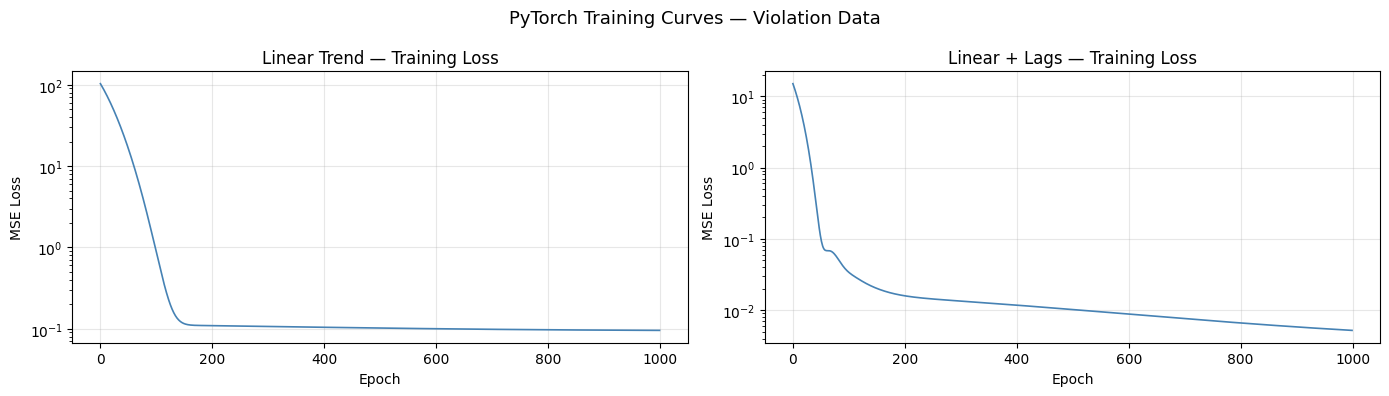

C:\Users\adity\AppData\Local\Temp\ipykernel_28952\3442465155.py:33: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  axes[0].plot(test_orig.index[:n1], pred_trend[:n1],
C:\Users\adity\AppData\Local\Temp\ipykernel_28952\3442465155.py:40: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  axes[1].plot(test_orig.index, pred_arima,


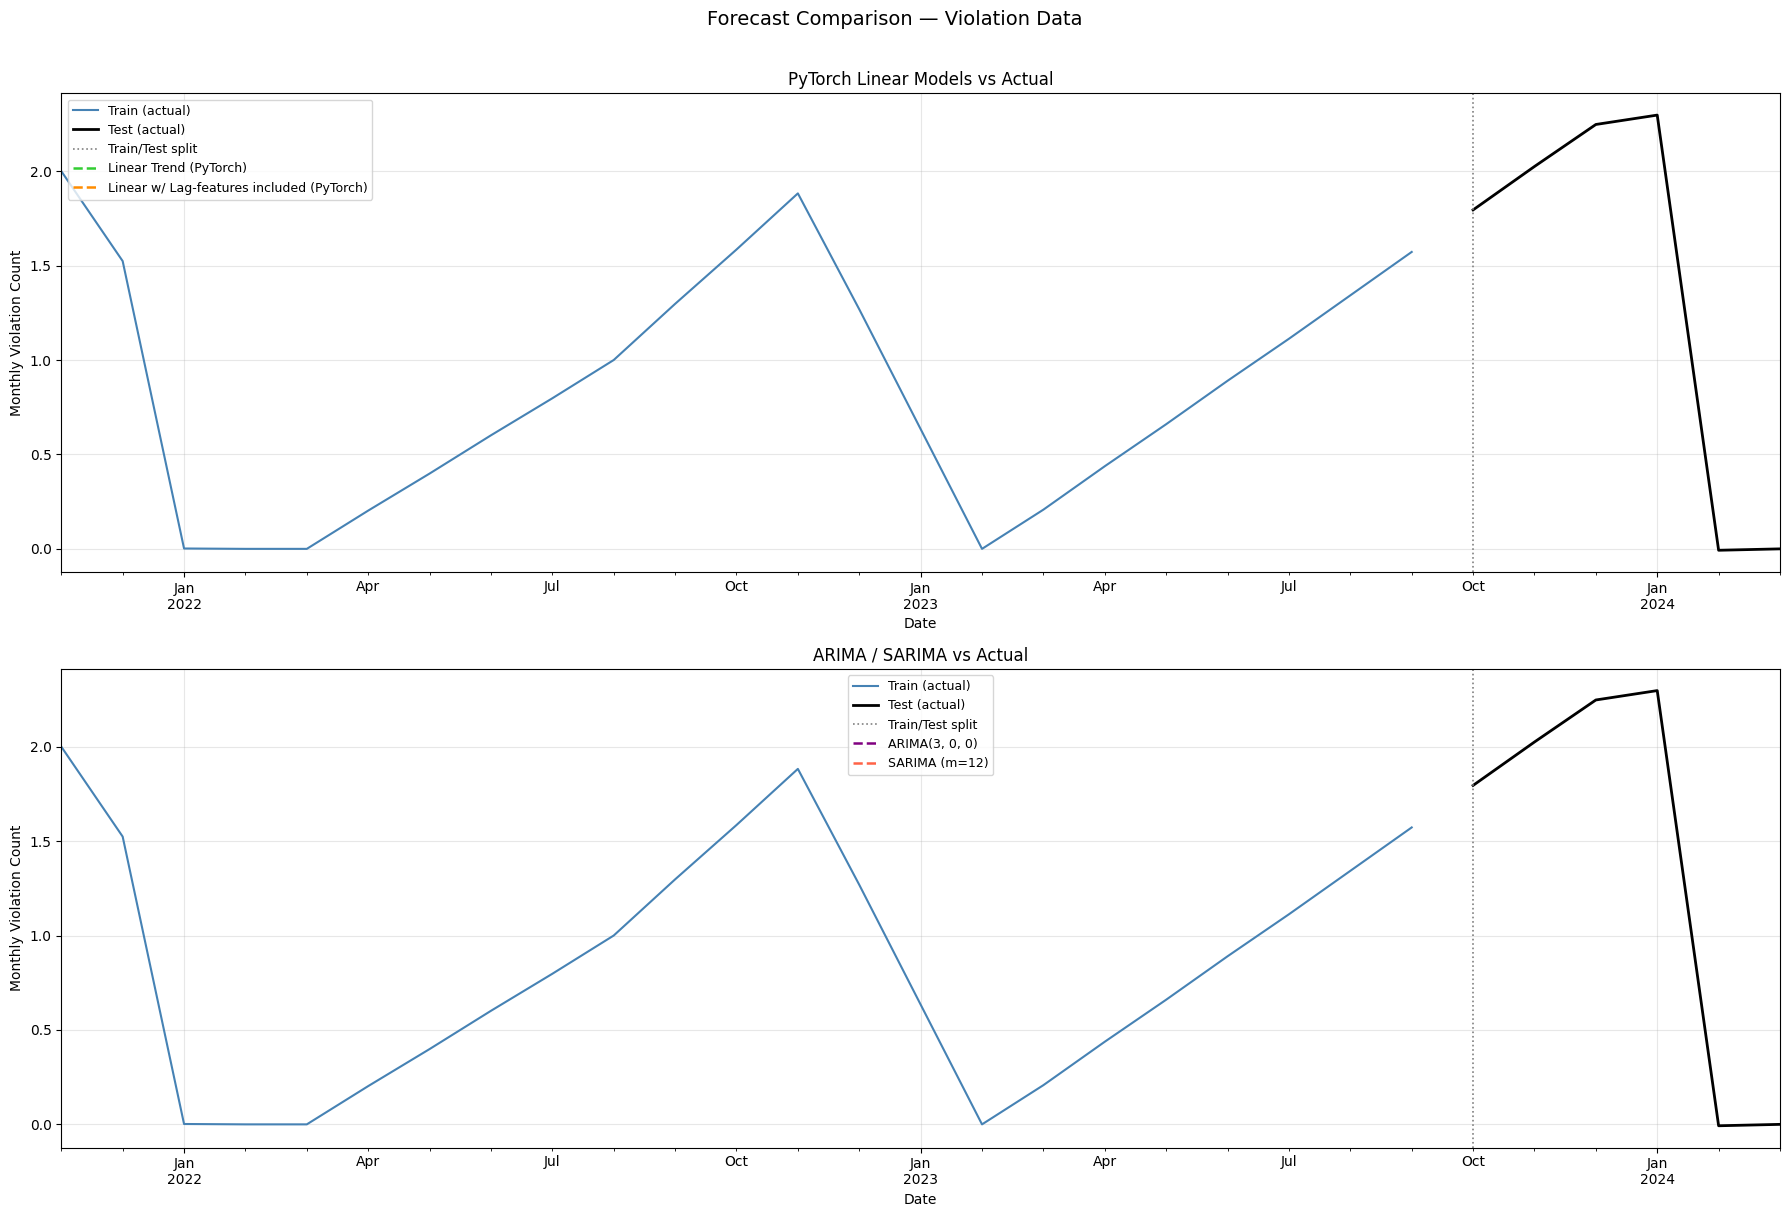

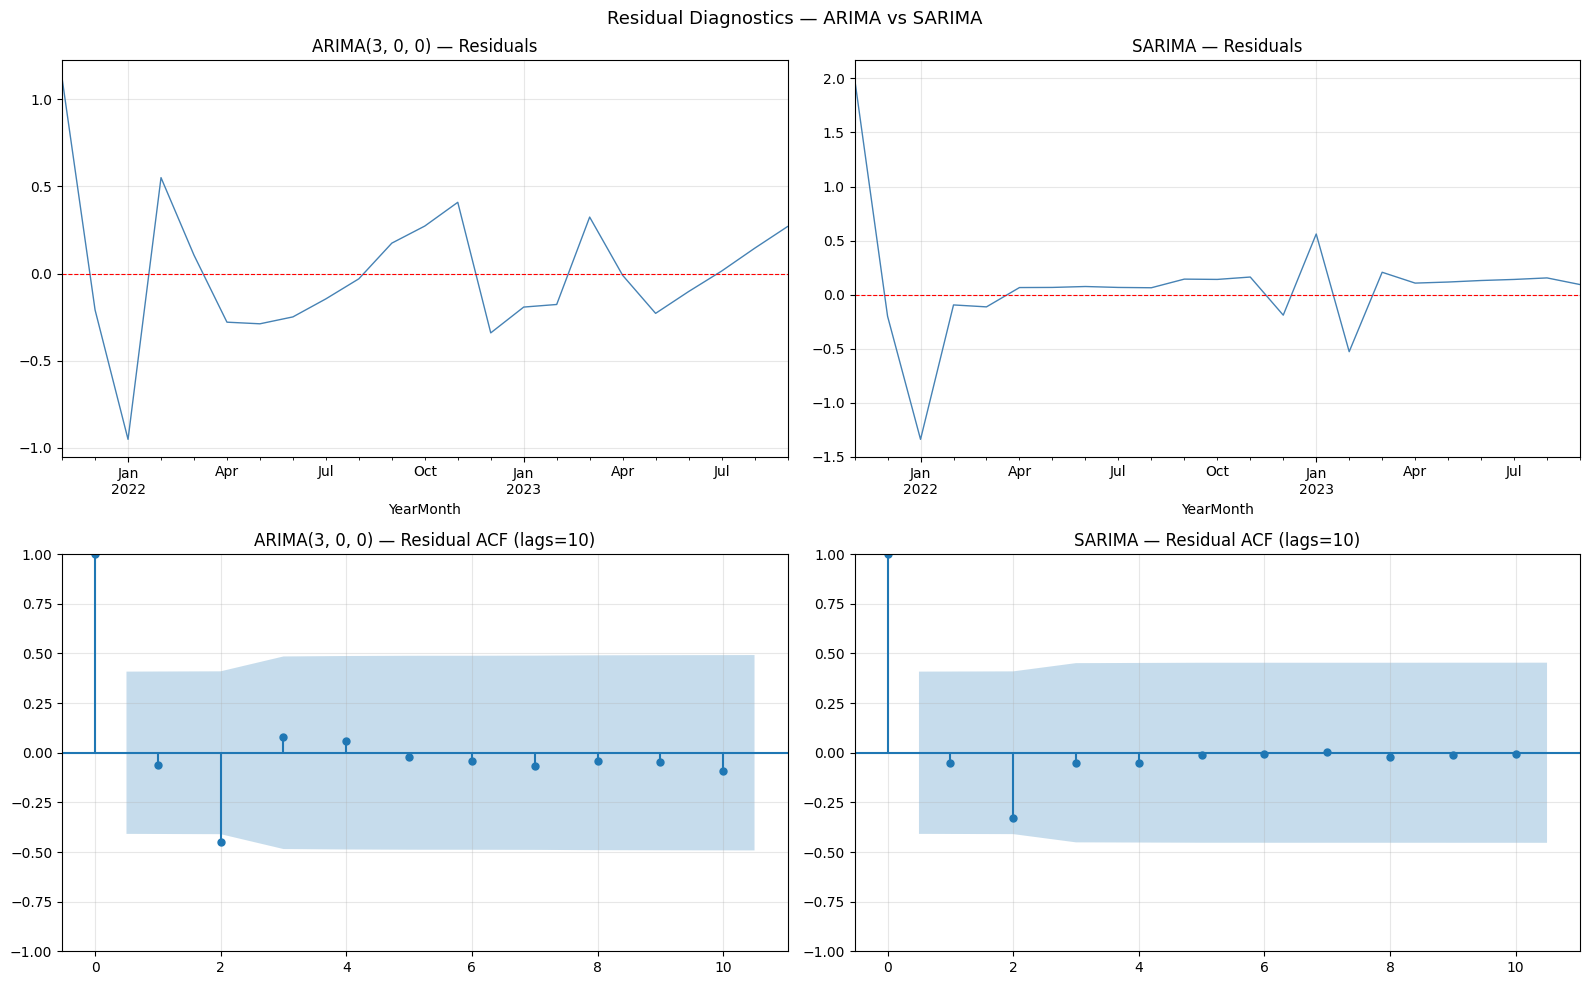


Residual Ljung-Box — ARIMA (max testable lag: 10):
    lb_stat  lb_pvalue
6  5.961271   0.427542

Residual Ljung-Box — SARIMA (max testable lag: 10):
    lb_stat  lb_pvalue
6  3.168322   0.787444


In [ ]:
# Forecast comparisons
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, losses, title in zip(
    axes,
    [losses_trend, losses_lag],
    ['Linear Trend', 'Linear + Lags']
):
    ax.plot(losses, color='steelblue', linewidth=1.2)
    ax.set_title(f'{title} — Training Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

plt.suptitle('PyTorch Training Curves — Violation Data', fontsize=13)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(18, 12))

for ax in axes:
    train_orig.plot(ax=ax, color='steelblue', linewidth=1.5, label='Train (actual)')
    test_orig.plot( ax=ax, color='black',     linewidth=2.0, label='Test (actual)')
    ax.axvline(x=test_orig.index[0], color='gray', linestyle=':', linewidth=1.2, label='Train/Test split')
    ax.grid(True, alpha=0.3)

n1 = min(len(test_orig),       len(pred_trend))
n2 = min(len(test_lag_actual), len(pred_lag))

axes[0].plot(test_orig.index[:n1], pred_trend[:n1], '--', color='limegreen',  linewidth=1.8, label='Linear Trend (PyTorch)')
axes[0].plot(test_orig.index[:n2], pred_lag[:n2], '--', color='darkorange', linewidth=1.8, label='Linear w/ Lag-features included (PyTorch)')
axes[0].set_title('PyTorch Linear Models vs Actual')
axes[0].legend(fontsize=9)

axes[1].plot(test_orig.index, pred_arima, '--', color='purple', linewidth=1.8, label=f"ARIMA{auto_arima_result.order}")
axes[1].plot(test_orig.index, pred_sarima, '--', color='tomato', linewidth=1.8, label='SARIMA (m=12)')
axes[1].set_title('ARIMA / SARIMA vs Actual')
axes[1].legend(fontsize=9)

for ax in axes:
    ax.set_xlabel('Date')
    ax.set_ylabel('Monthly Violation Count')

plt.suptitle('Forecast Comparison — Violation Data', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Residual diagnostics
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, (model, name) in enumerate([
    (arima_model,  f"ARIMA{auto_arima_result.order}"),
    (sarima_model, 'SARIMA')
]):
    resid = model.resid.dropna()

    # Cap lags at half the residual length minus 1 — statsmodels hard requirement
    max_lags = len(resid) // 2 - 1

    resid.plot(ax=axes[0][col], color='steelblue', linewidth=1.0)
    axes[0][col].axhline(0, color='red', linestyle='--', linewidth=0.8)
    axes[0][col].set_title(f'{name} — Residuals')
    axes[0][col].grid(True, alpha=0.3)

    plot_acf(resid, lags=max_lags, ax=axes[1][col])
    axes[1][col].set_title(f'{name} — Residual ACF (lags={max_lags})')
    axes[1][col].grid(True, alpha=0.3)

plt.suptitle('Residual Diagnostics — ARIMA vs SARIMA', fontsize=13)
plt.tight_layout()
plt.show()

for model, name in [(arima_model, 'ARIMA'), (sarima_model, 'SARIMA')]:
    resid    = model.resid.dropna()
    max_lags = len(resid) // 2 - 1
    # Only test at lags that actually exist in the residual series
    test_lags = [l for l in [6, 12, 24] if l <= max_lags]
    lb = acorr_ljungbox(resid, lags=test_lags, return_df=True)
    print(f"\nResidual Ljung-Box — {name} (max testable lag: {max_lags}):")
    print(lb.to_string())